In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import auc, roc_curve

In [99]:
class LogisticRegression(object):
    def __init__(self, X_train, y_train, X_test, y_test, learn_rate=0.001, n_iters=500):
        if len(X_train.shape) == 1:
            self.X_train = np.hstack((np.array([1]), X_train))
        else:
            self.X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
        self.y_train = y_train

        if len(X_test.shape) == 1:
            self.X_test = np.hstack((np.array([1]), X_test))
        else:
            self.X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
        self.y_test = y_test

        self.learn_rate = learn_rate
        self.n_iters = n_iters 

        # Initialize model weights
        self.weight = np.zeros((self.X_train.shape[1]))

        self.accuracy_train = []  # To keep track of accuracy on the training data during gradient ascent process
        self.accuracy_test = []  # To keep track of accuracy on the test data during gradient ascent process

        self.log_likelihood_train = []  # To keep track of average log likelihood on the training data during gradient ascent process
        self.log_likelihood_test = []  # To keep track of average log likelihood on the test data during gradient ascent process

    def predict(self, samples, threshold=0.5):
        return self.predict_prob(samples) >= threshold

    def predict_prob(self, samples):
        # Todo: Compute and return the predicted probability of each sample having an income >= 50K
        
        z = samples.dot(self.weight)
        sigmoid = 1 / (1 + np.exp(-z))
        return sigmoid

        # if len(samples.shape) == 1:
        #     samples = np.hstack((np.array([1]), samples))
        # else:
        #     ones = np.ones((samples.shape[0], 1))
        #     samples = np.hstack((ones, samples))
            
        # z = samples.dot(self.weight)
        # sigmoid = 1 / (1 + np.exp(-z))
        # return sigmoid
                        

    def compute_gradient(self, ):
        # Todo: compute and return gradient of the average log likelihood on the training set
        # training set

        p = self.predict_prob(self.X_train).reshape(-1, 1)
        diff = self.y_train.reshape(-1, 1)
        diff = diff - p
        grad = np.mean(self.X_train * diff, axis = 0)
        return grad

    def gradient_ascent(self, ):
        # Todo: Run gradient ascent to learn model weights
        # Todo: Store the average log likelihood and the prediction accuracy 
        #       on the training and test sets after every gradient ascent iteration
        
        for i in range(self.n_iters):
            self.weight = self.weight + self.learn_rate * self.compute_gradient()

            #accuracy
            train_pred = self.predict(self.X_train)
            train_accuracy = np.mean(train_pred == self.y_train)
            self.accuracy_train.append(train_accuracy)
            
            test_pred = self.predict(self.X_test)
            test_accuracy = np.mean(test_pred == self.y_test)
            self.accuracy_test.append(test_accuracy)

            # average log likelihood
            train = self.predict_prob(self.X_train)
                                    # for when y = 1                       # for when y = 0       
            log_train = np.mean(self.y_train * np.log(train)  + (1 - self.y_train) * np.log(1 - train) )
            self.log_likelihood_train.append(log_train)

            test = self.predict_prob(self.X_test)
            log_test = np.mean( self.y_test * np.log(test)  + (1 - self.y_test) * np.log(1 - test) )
            self.log_likelihood_test.append(log_test)
            

In [100]:
def preprocess_data(X_train, X_test):
    # Todo: encode categorical features using OneHotEncoder
    # Todo: standardize numerical features using StandardScaler()
    # Todo: return processed training and test sets

    categorical = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex']
    numerical = ['age', 'capital.gain', 'capital.loss', 'hours.per.week']

    ohe = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
    standard = StandardScaler()

    X_train_categorical = ohe.fit_transform(X_train[categorical])
    X_test_categorical = ohe.transform(X_test[categorical])

    X_train_numerical = standard.fit_transform(X_train[numerical])
    X_test_numerical = standard.transform(X_test[numerical])

    # hstack stacks arrays in sequence and combines them side by side into a single numpy array
    PX_train = np.hstack([X_train_categorical, X_train_numerical])
    PX_test = np.hstack([X_test_categorical, X_test_numerical])

    return PX_train, PX_test
    

In [121]:
def plot_log_likelihood_performance(log_likelihood_train, log_likelihood_test):
    # Todo: plot the average log likelihood curves of the training and test sets
    #      during training process

    plt.figure(figsize = (8, 6))
    plt.plot(np.arange(len(log_likelihood_train)), log_likelihood_train, label = 'training logL', color = 'red')
    plt.plot(np.arange(len(log_likelihood_train)), log_likelihood_test, label = 'test logl', color = 'blue')

    plt.title('Training Performance')
    plt.xlabel('Iterations')
    plt.ylabel('Average Log Likelihood')
    plt.legend(loc = 'lower right')
    

In [135]:
def plot_accuracy_performance(accuracy_train, accuracy_test):
    # Todo: plot the prediction accuracy curves of the training and test sets
    #      during the training process

    plt.figure(figsize = (8, 6))
    plt.plot(accuracy_train, label = 'training accuracy', color = 'red')
    plt.plot(accuracy_test, label = 'test accuracy', color = 'blue')

    plt.title('Prediction accuracy curves (training & test sets) during training process')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.legend(loc = 'lower right')
    

In [179]:
def plot_roc(X_train, y_train, X_test , y_test, learner):
    # Todo: plot the ROC curves 

    train = learner.predict_prob(learner.X_train)
    test = learner.predict_prob(learner.X_test)
    
#     fpr, tpr, ths = roc_curve(y_test, y_pred)
#     auc_val = auc(fpr, tpr)
    
    fprtrain, tprtrain, ths = roc_curve(y_train, train)
    fprtest, tprtest, ths = roc_curve(y_test, test)

    auc_train = auc(fprtrain, tprtrain)
    auc_test = auc(fprtest, tprtest)

    plt.figure(figsize = (8, 6))
    plt.plot(fprtrain, tprtrain, label = f'AUC = {auc_train:.2f}', color = 'red')
    plt.plot(fprtest, tprtest, label = f'AUC = {auc_test:.2f}', color = 'blue')
    
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc = 'lower right')
    

In [159]:
# Load data
train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')
X_train = train_data.drop(['income'], axis=1, inplace=False)
y_train = train_data['income']
X_test = test_data.drop(['income'], axis=1, inplace=False)
y_test = test_data['income']

y_train.replace({'<=50K': 0, '>50K': 1}, inplace=True)
y_test.replace({'<=50K': 0, '>50K': 1}, inplace=True)

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_8469/1727969331.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train.replace({'<=50K': 0, '>50K': 1}, inplace=True)
/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_8469/1727969331.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test.replace({'<=50K': 0, '>50K': 1}, inplace=True)


In [160]:
# Preprocessing data
processed_X_train, processed_X_test = preprocess_data(X_train, X_test)

In [196]:
# Run gradient ascent with Logistic Regression
learner = LogisticRegression(processed_X_train, y_train.values, processed_X_test, y_test.values,
                                 n_iters=700, learn_rate=0.75)
learner.gradient_ascent()

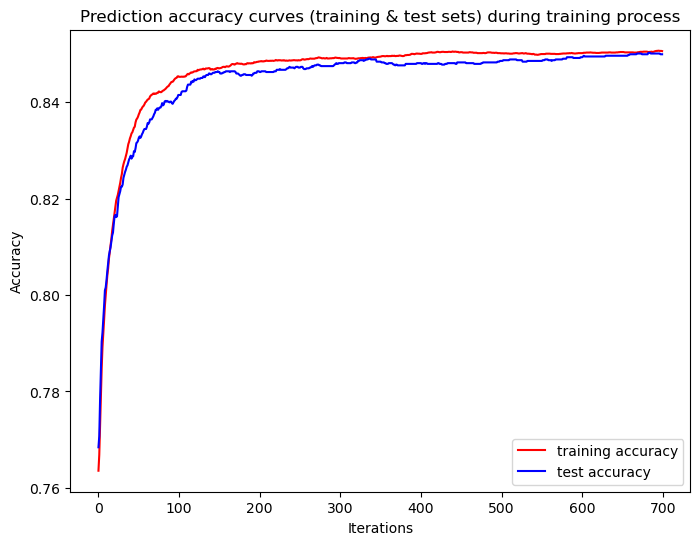

In [197]:
# Plot prediction accuracy during training process
plot_accuracy_performance(learner.accuracy_train, learner.accuracy_test)

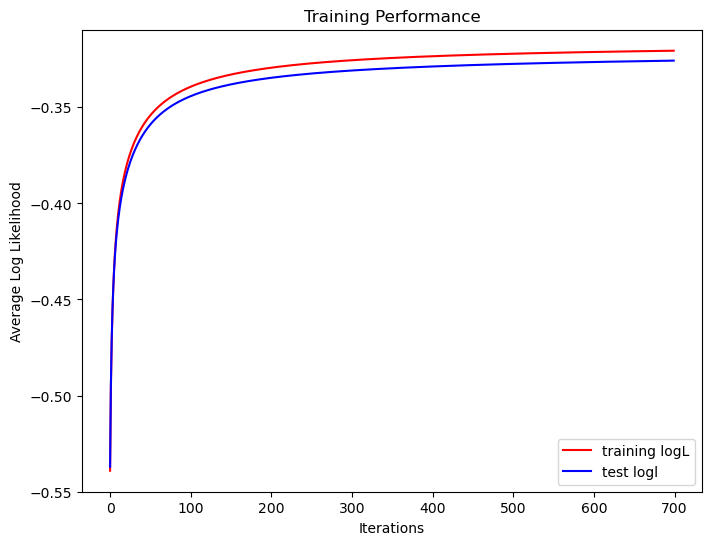

In [198]:
# Plot Log Likelihood values during training process
plot_log_likelihood_performance(learner.log_likelihood_train, learner.log_likelihood_test)

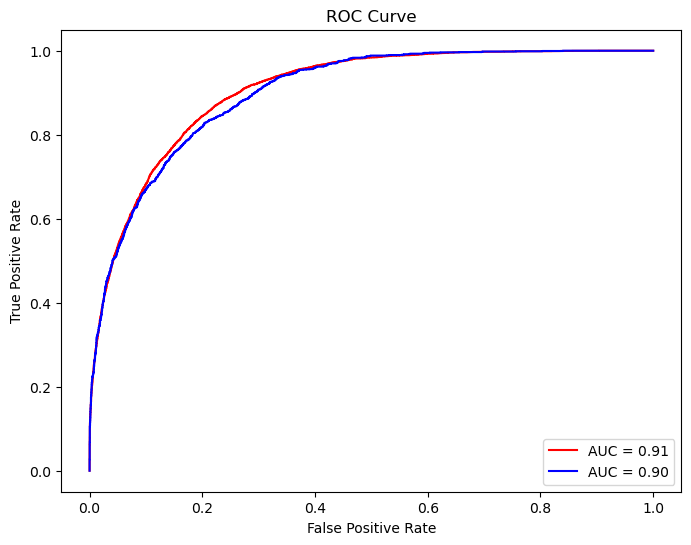

In [199]:
# Plot ROC curves
plot_roc(processed_X_train, y_train, processed_X_test, y_test, learner)

In [181]:
# y_train